In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns,warnings
warnings.filterwarnings('ignore')

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("changlechangsu/india-food-delivery-time-prediction")

# print("Path to dataset files:", path)

In [3]:
df=pd.read_json('../dataset/India-Food-Delivery-Time-Prediction.txt')
df.head(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33


In [4]:
df.drop(['ID','Delivery_person_ID'],axis=1,inplace=True)
df.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          40234 non-null  float64
 1   Delivery_person_Ratings      40190 non-null  float64
 2   Restaurant_latitude          41953 non-null  float64
 3   Restaurant_longitude         41953 non-null  float64
 4   Delivery_location_latitude   41953 non-null  float64
 5   Delivery_location_longitude  41953 non-null  float64
 6   Order_Date                   41953 non-null  object 
 7   Time_Orderd                  40353 non-null  object 
 8   Time_Order_picked            41953 non-null  object 
 9   Weatherconditions            41953 non-null  object 
 10  Road_traffic_density         41953 non-null  object 
 11  Vehicle_condition            41953 non-null  int64  
 12  Type_of_order                41953 non-null  object 
 13  Type_of_vehicle 

In [6]:
df.isnull().sum()

Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [7]:
df['Delivery_person_Age'].describe()

count    40234.000000
mean        29.563330
std          5.812361
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

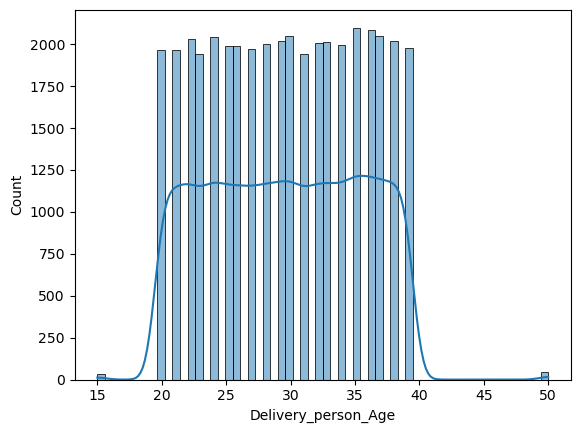

In [8]:
sns.histplot(df['Delivery_person_Age'], kde=True)
plt.show()

In [9]:
df['Delivery_person_Ratings'].describe()

count    40190.000000
mean         4.632386
std          0.335541
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

In [10]:
df[df['Delivery_person_Ratings']>5].shape

(46, 18)

In [11]:
df['Time_Orderd'].isnull().sum()

np.int64(1600)

In [12]:
df.shape

(41953, 18)

In [13]:
df['Delivery_person_Ratings']=df['Delivery_person_Ratings'].where((df['Delivery_person_Ratings']>=1) & (df['Delivery_person_Ratings']<=5))
# df=df[(df['Delivery_person_Ratings']>=1) & (df['Delivery_person_Ratings']<=5)]
df.shape

(41953, 18)

<Axes: xlabel='Delivery_person_Ratings', ylabel='Count'>

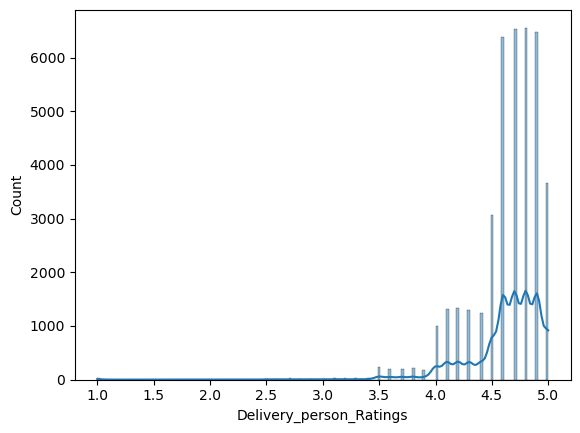

In [14]:
sns.histplot(df['Delivery_person_Ratings'],kde=True)

In [15]:
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(),inplace=True) #Outliers so using Median
df['Delivery_person_Ratings'].isnull().sum()

np.int64(0)

In [16]:
df['Time_Orderd'].isnull().sum()

np.int64(1600)

In [17]:
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(),inplace=True) #Outliers so using Median
df['Delivery_person_Age'].isnull().sum()

np.int64(0)

In [18]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [19]:
df['Time_Orderd'].isnull().sum()

np.int64(1600)

In [20]:
df['Time_Orderd']=pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S')
df['Time_Orderd'].dtype

dtype('<M8[ns]')

In [21]:
df['Time_Order_picked']=pd.to_datetime(df['Time_Order_picked'],format='%H:%M:%S')
df['Time_Order_picked'].dtype

dtype('<M8[ns]')

In [22]:
df['Time_Orderd'].isnull().sum()

np.int64(1600)

In [23]:
df['Time_Orderd'].fillna(df['Time_Orderd'].median(),inplace=True)

In [24]:

df['Ordered_Hour']=df['Time_Orderd'].dt.hour
df['Ordered_Minutes']=df['Time_Orderd'].dt.minute
# df['Ordered_Sec']=df['Time_Orderd'].dt.second # No Need
df.drop('Time_Orderd',axis=1,inplace=True)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,1900-01-01 11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,11,33
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,1900-01-01 19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,19,45
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,1900-01-01 08:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26,8,32
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,1900-01-01 18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21,18,3
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,1900-01-01 13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30,13,34


In [25]:
df['Picked_Hour']=df['Time_Order_picked'].dt.hour
df['Picked_Minutes']=df['Time_Order_picked'].dt.minute
# df['Picked_Sec']=df['Time_Order_picked'].dt.second #No need
df.drop('Time_Order_picked',axis=1,inplace=True)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,11,33,11,45
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,19,45,19,51
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26,8,32,8,48
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21,18,3,18,12
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30,13,34,13,45


In [26]:
df.isnull().sum()

Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Weatherconditions                0
Road_traffic_density             0
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            905
Festival                         0
City                             0
Time_taken(min)                  0
Ordered_Hour                     0
Ordered_Minutes                  0
Picked_Hour                      0
Picked_Minutes                   0
dtype: int64

In [27]:
df['multiple_deliveries'].describe()

count    41048.000000
mean         0.745249
std          0.572152
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: multiple_deliveries, dtype: float64

<Axes: xlabel='multiple_deliveries', ylabel='Count'>

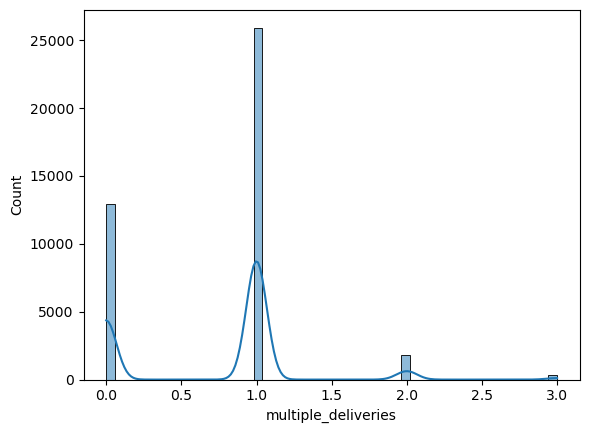

In [28]:
sns.histplot(df['multiple_deliveries'],kde=True)

In [29]:
# multiple_deliveries is a discrete count variable, not a continuous measurement so our only logical choice is Mode
df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0],inplace=True) #Mode give a series! so [0]
df['multiple_deliveries'].isnull().sum()

np.int64(0)

In [30]:
# sns.histplot(df['Hour_Ordered'],kde=True)

In [31]:
# sns.histplot(df['Minutes_Ordered'],kde=True)

In [32]:
# sns.histplot(df['Sec_Ordered'],kde=True)

# Day 2

In [33]:
df.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,11,33,11,45
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,19,45,19,51


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41953 non-null  float64
 1   Delivery_person_Ratings      41953 non-null  float64
 2   Restaurant_latitude          41953 non-null  float64
 3   Restaurant_longitude         41953 non-null  float64
 4   Delivery_location_latitude   41953 non-null  float64
 5   Delivery_location_longitude  41953 non-null  float64
 6   Order_Date                   41953 non-null  object 
 7   Weatherconditions            41953 non-null  object 
 8   Road_traffic_density         41953 non-null  object 
 9   Vehicle_condition            41953 non-null  int64  
 10  Type_of_order                41953 non-null  object 
 11  Type_of_vehicle              41953 non-null  object 
 12  multiple_deliveries          41953 non-null  float64
 13  Festival        

In [35]:
df.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
Ordered_Hour                   0
Ordered_Minutes                0
Picked_Hour                    0
Picked_Minutes                 0
dtype: int64

In [36]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')
df['Order_Date'].dtype

dtype('<M8[ns]')

In [37]:
df.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,11,33,11,45
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,19,45,19,51


In [38]:
df['Order_Date'].dt.year.value_counts()

Order_Date
2022    41953
Name: count, dtype: int64

In [39]:
df['Order_Day']=df['Order_Date'].dt.day
df['Order_Month']=df['Order_Date'].dt.month
df['Order_Day_of_Week'] = df['Order_Date'].dt.dayofweek
df.drop('Order_Date',axis=1,inplace=True)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes,Order_Day,Order_Month,Order_Day_of_Week
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,conditions Sunny,High,2,Snack,...,No,Urban,(min) 24,11,33,11,45,19,3,5
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,conditions Stormy,Jam,2,Snack,...,No,Metropolitian,(min) 33,19,45,19,51,25,3,4
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,conditions Sandstorms,Low,0,Drinks,...,No,Urban,(min) 26,8,32,8,48,19,3,5
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,conditions Sunny,Medium,0,Buffet,...,No,Metropolitian,(min) 21,18,3,18,12,5,4,1
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,conditions Cloudy,High,1,Snack,...,No,Metropolitian,(min) 30,13,34,13,45,26,3,5


In [40]:
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64

In [41]:
df['Weatherconditions']=df['Weatherconditions'].str.replace('conditions ','')
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
NaN            569
Name: count, dtype: int64

In [42]:
df['Weatherconditions']=df['Weatherconditions'].str.replace('NaN',df['Weatherconditions'].mode()[0])
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           7581
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64

In [43]:
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: count, dtype: int64

In [44]:
df['Road_traffic_density'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [45]:
df['Road_traffic_density']=df['Road_traffic_density'].str.replace(" ","")
df['Road_traffic_density'].unique()

array(['High', 'Jam', 'Low', 'Medium', 'NaN'], dtype=object)

In [46]:
df['Road_traffic_density'] = df['Road_traffic_density'].str.strip() #Better Way!

In [47]:
df['Road_traffic_density']=df['Road_traffic_density'].str.replace("NaN",df['Road_traffic_density'].mode()[0])
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low       14755
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64

In [48]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes,Order_Day,Order_Month,Order_Day_of_Week
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,No,Urban,(min) 24,11,33,11,45,19,3,5
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,No,Metropolitian,(min) 33,19,45,19,51,25,3,4
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,...,No,Urban,(min) 26,8,32,8,48,19,3,5
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,...,No,Metropolitian,(min) 21,18,3,18,12,5,4,1
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,...,No,Metropolitian,(min) 30,13,34,13,45,26,3,5


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41953 non-null  float64
 1   Delivery_person_Ratings      41953 non-null  float64
 2   Restaurant_latitude          41953 non-null  float64
 3   Restaurant_longitude         41953 non-null  float64
 4   Delivery_location_latitude   41953 non-null  float64
 5   Delivery_location_longitude  41953 non-null  float64
 6   Weatherconditions            41953 non-null  object 
 7   Road_traffic_density         41953 non-null  object 
 8   Vehicle_condition            41953 non-null  int64  
 9   Type_of_order                41953 non-null  object 
 10  Type_of_vehicle              41953 non-null  object 
 11  multiple_deliveries          41953 non-null  float64
 12  Festival                     41953 non-null  object 
 13  City            

In [50]:
df['Vehicle_condition'].unique()

array([2, 0, 1, 3])

In [51]:
df['Type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [52]:
df['Type_of_order']=df['Type_of_order'].str.strip()
df['Type_of_order'].unique()

array(['Snack', 'Drinks', 'Buffet', 'Meal'], dtype=object)

In [53]:
df['Type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [54]:
df['Type_of_vehicle']=df['Type_of_vehicle'].str.strip()
df['Type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

In [55]:
df['Festival'].unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [56]:
for i in df.columns:
    if df[i].dtype=='O':
        df[i]=df[i].str.strip()

In [57]:
df['Festival'].unique()

array(['No', 'Yes', 'NaN'], dtype=object)

In [58]:
df.replace('NaN',np.nan,inplace=True)

In [59]:
df['Festival'].unique()

array(['No', 'Yes', nan], dtype=object)

In [60]:
df.isnull().sum()

Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                        215
City                           1114
Time_taken(min)                   0
Ordered_Hour                      0
Ordered_Minutes                   0
Picked_Hour                       0
Picked_Minutes                    0
Order_Day                         0
Order_Month                       0
Order_Day_of_Week                 0
dtype: int64

In [61]:
df['Festival'].fillna(df['Festival'].mode()[0],inplace=True)

In [62]:
df['City'].fillna(df['City'].mode()[0],inplace=True)

In [63]:
df['City'].unique()

array(['Urban', 'Metropolitian', 'Semi-Urban'], dtype=object)

In [64]:
df.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,Festival,City,Time_taken(min),Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes,Order_Day,Order_Month,Order_Day_of_Week
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,No,Urban,(min) 24,11,33,11,45,19,3,5
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,No,Metropolitian,(min) 33,19,45,19,51,25,3,4


In [65]:
df['Time_taken']=df['Time_taken(min)'].str.replace("(min) ","").astype(int)
df.drop('Time_taken(min)',axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41953 non-null  float64
 1   Delivery_person_Ratings      41953 non-null  float64
 2   Restaurant_latitude          41953 non-null  float64
 3   Restaurant_longitude         41953 non-null  float64
 4   Delivery_location_latitude   41953 non-null  float64
 5   Delivery_location_longitude  41953 non-null  float64
 6   Weatherconditions            41953 non-null  object 
 7   Road_traffic_density         41953 non-null  object 
 8   Vehicle_condition            41953 non-null  int64  
 9   Type_of_order                41953 non-null  object 
 10  Type_of_vehicle              41953 non-null  object 
 11  multiple_deliveries          41953 non-null  float64
 12  Festival                     41953 non-null  object 
 13  City            

In [66]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,Festival,City,Ordered_Hour,Ordered_Minutes,Picked_Hour,Picked_Minutes,Order_Day,Order_Month,Order_Day_of_Week,Time_taken
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,No,Urban,11,33,11,45,19,3,5,24
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,No,Metropolitian,19,45,19,51,25,3,4,33
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,...,No,Urban,8,32,8,48,19,3,5,26
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,...,No,Metropolitian,18,3,18,12,5,4,1,21
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,...,No,Metropolitian,13,34,13,45,26,3,5,30


In [67]:
for i in df.columns:
    if df[i].dtype=="O":
        print(df[i].value_counts())
        print()

Weatherconditions
Fog           7581
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64

Road_traffic_density
Low       14755
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64

Type_of_order
Snack     10616
Meal      10524
Drinks    10445
Buffet    10368
Name: count, dtype: int64

Type_of_vehicle
motorcycle          24396
scooter             14029
electric_scooter     3468
bicycle                60
Name: count, dtype: int64

Festival
No     41131
Yes      822
Name: count, dtype: int64

City
Metropolitian    32525
Urban             9279
Semi-Urban         149
Name: count, dtype: int64



In [68]:
for i in df.columns:
    if df[i].dtype=='O':
        print(i)

Weatherconditions
Road_traffic_density
Type_of_order
Type_of_vehicle
Festival
City


In [69]:
df['Festival']=df['Festival'].map(
    {
        'No':0,
        'Yes':1
    }
)

In [70]:
# df.to_json('../dataset/Cleaned_Data.json',index=False)

In [71]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Ordered_Hour', 'Ordered_Minutes', 'Picked_Hour', 'Picked_Minutes',
       'Order_Day', 'Order_Month', 'Order_Day_of_Week', 'Time_taken'],
      dtype='object')